# GEOG 6240 Lab 5 - Change Detection in the Southern Ontario Region Using Remote Sensing.

## Set Up Directory

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/6420- Lab 5/Lab5_data/"

In [ ]:
import os
os.listdir(path)

['LSDS-1619_Landsat8-9-Collection2-Level2-Science-Product-Guide-v5.pdf',
 '.DS_Store',
 '2014',
 '2024',
 'mask.tif',
 'mask_2024.tif',
 'mask_2014.tif',
 'ndvi_change.tif',
 'ndvi_change_2.tif',
 'ndvi_2014.tif',
 'regression_residuals.tif',
 'regression_results.html',
 'ndvi_2024.tif',
 'regression_residuals_filtered.tif',
 'urban_expansion.shp',
 'urban_expansion.shx',
 'urban_expansion.prj',
 'urban_expansion.dbf',
 '2024_NC.tif',
 '2014_NC.tif',
 '2014_NC_Mask.tif',
 '2024_NC_Mask.tif',
 'training_2014']

## Install Whitebox Workflows & Read Rasters

In [ ]:
pip install whitebox_workflows

In [ ]:
import whitebox_workflows
# set up Whitebox environment
wbe = whitebox_workflows.WbEnvironment()
wbe.working_directory = path  # update with a real directory
wbe.verbose = True  # optional: set to False to reduce console output

In [ ]:
os.listdir(path + "2014/")

['LC08_L1TP_018030_20140819_20200911_02_T1_B8.TIF.aux.xml',
 '.DS_Store',
 'LC08_L1TP_018030_20140819_20200911_02_T1_B8_clipped.TIF',
 'LC08_L2SP_018030_20140819_20200911_02_T1_SR_B3_clipped.TIF',
 'LC08_L2SP_018030_20140819_20200911_02_T1_SR_B6_clipped.TIF',
 'LC08_L2SP_018030_20140819_20200911_02_T1_QA_PIXEL_clipped.TIF.aux.xml',
 'LC08_L2SP_018030_20140819_20200911_02_T1_SR_B4_clipped.TIF.aux.xml',
 'LC08_L2SP_018030_20140819_20200911_02_T1_SR_B1_clipped.TIF',
 'LC08_L2SP_018030_20140819_20200911_02_T1_SR_B5_clipped.TIF',
 'LC08_L2SP_018030_20140819_20200911_02_T1_MTL.txt',
 'LC08_L2SP_018030_20140819_20200911_02_T1_SR_B4_clipped.TIF',
 'LC08_L2SP_018030_20140819_20200911_02_T1_SR_B7_clipped.TIF',
 'LC08_L2SP_018030_20140819_20200911_02_T1_QA_PIXEL_clipped.TIF',
 'LC08_L2SP_018030_20140819_20200911_02_T1_SR_B2_clipped.TIF',
 'LC08_L2SP_018030_20140819_20200911_02_T1_ST_B10_clipped.TIF']

In [ ]:
os.listdir(path + "2024/")

['LC08_L1TP_018030_20240814_20240822_02_T1_B8_clipped.TIF',
 'LC08_L2SP_018030_20240814_20240822_02_T1_SR_B2_clipped.TIF',
 'LC08_L2SP_018030_20240814_20240822_02_T1_SR_B7_clipped.TIF',
 'LC08_L2SP_018030_20240814_20240822_02_T1_QA_PIXEL_clipped.TIF',
 'LC08_L2SP_018030_20240814_20240822_02_T1_SR_B4_clipped.TIF.aux.xml',
 'LC08_L2SP_018030_20240814_20240822_02_T1_SR_B6_clipped.TIF',
 'LC08_L2SP_018030_20240814_20240822_02_T1_SR_B1_clipped.TIF',
 'LC08_L2SP_018030_20240814_20240822_02_T1_MTL.txt',
 'LC08_L2SP_018030_20240814_20240822_02_T1_SR_B4_clipped.TIF',
 '.DS_Store',
 'LC08_L2SP_018030_20240814_20240822_02_T1_QA_PIXEL_clipped.TIF.aux.xml',
 'LC08_L2SP_018030_20240814_20240822_02_T1_SR_B5_clipped.TIF',
 'LC08_L2SP_018030_20240814_20240822_02_T1_SR_B3_clipped.TIF',
 'LC08_L2SP_018030_20240814_20240822_02_T1_ST_B10_clipped.TIF']

In [ ]:
# define base paths
p2014 = path + "2014/"
p2024 = path + "2024/"

# 2014 bands
b2_2014 = wbe.read_raster(p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B2_clipped.TIF")
b3_2014 = wbe.read_raster(p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B3_clipped.TIF")
b4_2014 = wbe.read_raster(p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B4_clipped.TIF")
b5_2014 = wbe.read_raster(p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B5_clipped.TIF")
b6_2014 = wbe.read_raster(p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B6_clipped.TIF")
b7_2014 = wbe.read_raster(p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B7_clipped.TIF")
qa_2014 = wbe.read_raster(p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_QA_PIXEL_clipped.TIF")

# 2024 bands
b2_2024 = wbe.read_raster(p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B2_clipped.TIF")
b3_2024 = wbe.read_raster(p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B3_clipped.TIF")
b4_2024 = wbe.read_raster(p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B4_clipped.TIF")
b5_2024 = wbe.read_raster(p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B5_clipped.TIF")
b6_2024 = wbe.read_raster(p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B6_clipped.TIF")
b7_2024 = wbe.read_raster(p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B7_clipped.TIF")
qa_2024 = wbe.read_raster(p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_QA_PIXEL_clipped.TIF")

## Create a RGB Colour Composit

In [ ]:
# --- 2014 Natural Color (RGB: 4,3,2) ---
colour_comp_2014 = wbe.create_colour_composite(
    red=b4_2014,
    green=b3_2014,
    blue=b2_2014,
    enhance=False
)

wbe.write_raster(
    colour_comp_2014,
    path + "2014_NC.tif",
    compress=True
)


# --- 2024 Natural Color (RGB: 4,3,2) ---
colour_comp_2024 = wbe.create_colour_composite(
    red=b4_2024,
    green=b3_2024,
    blue=b2_2024,
    enhance=False,
)

wbe.write_raster(
    colour_comp_2024,
    path + "2024_NC.tif",
    compress=True
)

## Create a Cloud Mask

## Change Detection

### Technique 1 - NDVI

In [ ]:
try:

    red_2014 = b4_2014
    nir_2014 = b5_2014

    red_2024 = b4_2024
    nir_2024 = b5_2024

    # Create NDVI for both years
    ndvi_2014 = wbe.normalized_difference_index(nir_2014, red_2014, clip_percent = 0.0, correction_value = 0.0)
    ndvi_2024 = wbe.normalized_difference_index(nir_2024, red_2024, clip_percent = 0.0, correction_value = 0.0)

    # Calculate the change in NDVI
    ndvi_change = ndvi_2024 - ndvi_2014
    wbe.write_raster(ndvi_change, "ndvi_change.tif")

    print("All done!")

except Exception as e:
    print(f"An error occurred: {e}")

All done!


In [ ]:
from whitebox_workflows import WbEnvironment

try:

    qa_2014 = wbe.read_raster(p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_QA_PIXEL_clipped.TIF")
    qa_2024 = wbe.read_raster(p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_QA_PIXEL_clipped.TIF")

    mask_2014 = qa_2014 == 21824
    mask_2024 = qa_2024 == 21824

    mask = mask_2014 * mask_2024

    wbe.write_raster(mask, path + "mask.tif", compress=True)

except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
# NDVI
ndvi_2014 = wbe.normalized_difference_index(b5_2014, b4_2014)
ndvi_2024 = wbe.normalized_difference_index(b5_2024, b4_2024)

# Masks
mask = mask_2014 * mask_2024

# Apply mask
ndvi_2014 = ndvi_2014 * mask_2014
ndvi_2024 = ndvi_2024 * mask_2024

# NDVI change
ndvi_change_2 = (ndvi_2024 - ndvi_2014) * mask

# Save
wbe.write_raster(ndvi_change_2, "ndvi_change_2.tif")

### Technique 2 - Image Regression

In [ ]:
  # write ndvi rastersfor visual inspection
  wbe.write_raster(ndvi_2014, "ndvi_2014.tif")
  wbe.write_raster(ndvi_2024, "ndvi_2024.tif")

  #perform image regression
  regression_residuals = wbe.image_regression(
      independent_variable = ndvi_2014,
      dependent_variable = ndvi_2024,
      output_html_file = "regression_results.html",
      standardize_residuals = False,
      output_scattergram = False,
      num_samples= 10000)

  regression_residuals = (abs(regression_residuals) > 0.0758*2.5) * regression_residuals
  wbe.write_raster(regression_residuals, "regression_residuals.tif")

In [ ]:
# Apply median filter to regression residuals

median_size = 3  #3x3 filter

regression_residuals_filtered = wbe.median_filter(
    raster=regression_residuals,
    filter_size_x=median_size,
    filter_size_y=median_size
)

# Save output
wbe.write_raster(
    regression_residuals_filtered,
    path + "regression_residuals_filtered.tif",
    compress=True
)

In [ ]:
# Urban expansion from filtered residuals
urban_expansion = regression_residuals_filtered < 0.0

# Convert to polygons
urban_expansion_polys = wbe.raster_to_vector_polygons(urban_expansion)

# Save
wbe.write_vector(urban_expansion_polys, "urban_expansion.shp")

### Technique 3 Random Forest Classification & Post Classification Change Detection

In [ ]:
os.listdir(path + "training_2014/")

['training_2014.prj',
 'training_2014.cpg',
 'training_2014.shp',
 'training_2014.shx',
 'training_2014.dbf']

In [ ]:
p_training = path + "training_2014/"

In [ ]:
license_id = 'geog3420-w26' # Update this string to the floating-license ID provided by your TA
wbe = whitebox_workflows.WbEnvironment(license_id)

try:
    wbe.max_procs = -1

    # Read the 7 bands of data into a variable named 'band_data'
    print('Reading band data...')
    band_data_2014 = wbe.read_rasters(
     p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B2_clipped.TIF",
     p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B3_clipped.TIF",
     p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B4_clipped.TIF",
     p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B5_clipped.TIF",
     p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B6_clipped.TIF",
     p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_SR_B7_clipped.TIF"
    )

    # Read in the training data
    print('Reading training data...')
    training_data = wbe.read_vector(p_training + 'training_2014.shp')

    # Train the model
    model_2014 = wbe.random_forest_classification_fit(
        band_data_2014,
        training_data,
        class_field_name = 'Class',
        split_criterion = "Gini",
        n_trees = 100,
        min_samples_leaf = 1,
        min_samples_split = 2,
        test_proportion = 0.2
    )

    # Use the model to predict
    rf_class_image_2014 = wbe.random_forest_classification_predict(band_data_2014, model_2014)

    # Save the output raster to disc
    wbe.write_raster(rf_class_image_2014, path + 'rf_classification_2014.tif', compress=True)

    print("Operation complete!") # Provide some sort of indication that the job is done.

except Exception as e:
    print(f"Exception: {e}")

finally:
    print(wbe.check_in_license(license_id)) # Check your license back in.


Reading band data...
Reading training data...
Operation complete!
Successful license check-in


In [ ]:
license_id = 'geog3420-w26' # Update this string to the floating-license ID provided by your TA
wbe = whitebox_workflows.WbEnvironment(license_id)

try:
    wbe.max_procs = -1

    # Read the 7 bands of data into a variable named 'band_data'
    print('Reading band data...')

    band_data_2024 = wbe.read_rasters(
      p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B2_clipped.TIF",
      p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B3_clipped.TIF",
      p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B4_clipped.TIF",
      p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B5_clipped.TIF",
      p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B6_clipped.TIF",
      p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_SR_B7_clipped.TIF"
    )

    # Use the model to predict
    rf_class_image_2024 = wbe.random_forest_classification_predict(band_data_2024, model_2014)

    # Save the output raster to disc
    wbe.write_raster(rf_class_image_2024, path + 'rf_classification_2024.tif', compress=True)

    print("Operation complete!") # Provide some sort of indication that the job is done.

except Exception as e:
    print(f"Exception: {e}")

finally:
    print(wbe.check_in_license(license_id)) # Check your license back in.



Reading band data...
Operation complete!
Successful license check-in


In [ ]:
license_id = 'geog3420-w26'
wbe = whitebox_workflows.WbEnvironment(license_id)

try:

    # Read raster into memory (IMPORTANT FIX)
    print('Reading RF classification raster...')
    rf_2014 = wbe.read_raster(path + 'rf_classification_2014.tif')
    rf_2024 = wbe.read_raster(path + 'rf_classification_2024.tif')

    # 5x5 filter
    print('Applying 5x5 majority filter...')
    mf_2014 = wbe.majority_filter(
        rf_2014,
        filter_size_x=5,
        filter_size_y=5
    )
    wbe.write_raster(mf_2014, path + 'rf_majority_5x5_2014.tif', compress=True)

    # 5x5 filter
    print('Applying 5x5 majority filter...')
    mf_2024 = wbe.majority_filter(
        rf_2024,
        filter_size_x=5,
        filter_size_y=5
    )
    wbe.write_raster(mf_2024, path + 'rf_majority_5x5_2024.tif', compress=True)

    print("All done!")

except Exception as e:
    print(f"Error: {e}")

finally:
    wbe.check_in_license(license_id)


Reading RF classification raster...
Applying 5x5 majority filter...
Applying 5x5 majority filter...
All done!


In [ ]:
#Read in 5x5 Majority Filtered Random Forest Classified Images
rf_2014 = wbe.read_raster(path + "rf_majority_5x5_2014.tif")
rf_2024 = wbe.read_raster(path + "rf_majority_5x5_2024.tif")

wbe.cross_tabulation(
    raster1=rf_2014,
    raster2=rf_2024,
    output_html_file=path + "change_matrix.html"
)

In [ ]:
rf_2014 = wbe.read_raster(path + "rf_majority_5x5_2014.tif")
rf_2024 = wbe.read_raster(path + "rf_majority_5x5_2024.tif")

change_map = rf_2014 * 10 + rf_2024

wbe.write_raster(change_map, path + "rf_change_map.tif", compress=True)

In [ ]:
import pandas as pd

# manually input your matrix
matrix = pd.DataFrame([
    [1089715,129273,15562,29703,34126,1980],
    [14632,96895,7,794,112,322],
    [87928,568,442427,40939,3416,838],
    [201569,73886,66453,1105718,4257,4503],
    [47960,297,653,264,5278,1],
    [893,244,2368,864,0,2918388]
])

# labels
labels = ["Forest","Industrial","Crops","Residential","Soil","Water"]

matrix.index = labels
matrix.columns = labels

print(matrix)

              Forest  Industrial   Crops  Residential   Soil    Water
Forest       1089715      129273   15562        29703  34126     1980
Industrial     14632       96895       7          794    112      322
Crops          87928         568  442427        40939   3416      838
Residential   201569       73886   66453      1105718   4257     4503
Soil           47960         297     653          264   5278        1
Water            893         244    2368          864      0  2918388


/tmp/ipykernel_5820/2070193543.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_fmt = df.applymap(lambda x: f"{x:,}")


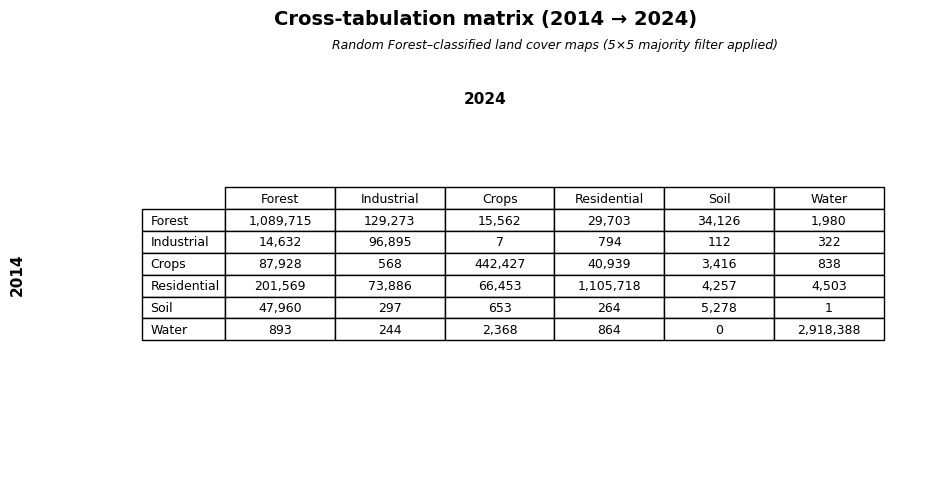

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Data ---
data = [
    [1089715,129273,15562,29703,34126,1980],
    [14632,96895,7,794,112,322],
    [87928,568,442427,40939,3416,838],
    [201569,73886,66453,1105718,4257,4503],
    [47960,297,653,264,5278,1],
    [893,244,2368,864,0,2918388]
]

labels = ["Forest","Industrial","Crops","Residential","Soil","Water"]

df = pd.DataFrame(data, index=labels, columns=labels)
df_fmt = df.applymap(lambda x: f"{x:,}")

# --- Figure ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.axis('off')

# --- Titles ---
plt.suptitle(
    "Cross-tabulation matrix (2014 → 2024)",
    fontsize=14, weight='bold', y=0.96
)

plt.title(
    "Random Forest–classified land cover maps (5×5 majority filter applied)",
    fontsize=9, style='italic', pad=4
)

# --- Table ---
table = ax.table(
    cellText=df_fmt.values,
    rowLabels=df_fmt.index,
    colLabels=df_fmt.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(0.9, 1.2)

# --- Labels (FIXED POSITIONING) ---

# Date 2 (top)
plt.text(
    0.5, 0.78, "2024",
    ha='center', va='center',
    fontsize=11, weight='bold',
    transform=fig.transFigure
)

# Date 1 (moved LEFT so it doesn't overlap)
plt.text(
    -0.02, 0.43, "2014",
    ha='center', va='center',
    rotation='vertical',
    fontsize=11, weight='bold',
    transform=fig.transFigure
)

# --- Layout tightening ---
plt.tight_layout()

# Save
plt.savefig(path + "rf_change_matrix.png", bbox_inches='tight', dpi=300)

plt.show()

## Discard Pile Below

In [ ]:
### xxx Skip step xxx ###

# --- APPLY MASK TO INDIVIDUAL BANDS FIRST ---

# 2014 bands
b4_2014_mask = b4_2014 * mask_2014
b3_2014_mask = b3_2014 * mask_2014
b2_2014_mask = b2_2014 * mask_2014

# 2024 bands
b4_2024_mask = b4_2024 * mask_2024
b3_2024_mask = b3_2024 * mask_2024
b2_2024_mask = b2_2024 * mask_2024


# --- CREATE RGB COMPOSITES (Natural Color: 4-3-2) ---

colour_comp_2014 = wbe.create_colour_composite(
    red=b4_2014_mask,
    green=b3_2014_mask,
    blue=b2_2014_mask,
    enhance=True   # improves contrast automatically
)

colour_comp_2024 = wbe.create_colour_composite(
    red=b4_2024_mask,
    green=b3_2024_mask,
    blue=b2_2024_mask,
    enhance=True
)


# --- SAVE OUTPUTS ---

wbe.write_raster(
    colour_comp_2014,
    "2014_NC_Mask.tif",
    compress=True
)

wbe.write_raster(
    colour_comp_2024,
    "2024_NC_Mask.tif",
    compress=True
)

In [ ]:
### XXX Not Required XXX

from whitebox_workflows import WbEnvironment

try:

    qa_2014 = wbe.read_raster(p2014 + "LC08_L2SP_018030_20140819_20200911_02_T1_QA_PIXEL_clipped.TIF")
    qa_2024 = wbe.read_raster(p2024 + "LC08_L2SP_018030_20240814_20240822_02_T1_QA_PIXEL_clipped.TIF")

    mask_2014 = qa_2014 == 21824
    mask_2024 = qa_2024 == 21824

   # wbe.write_raster(mask_2014, path + "mask_2014.tif", compress=True)
   # wbe.write_raster(mask_2024, path + "mask_2024.tif", compress=True)

except Exception as e:
    print(f"An error occurred: {e}")